<a href="https://colab.research.google.com/github/Yugansh-Varshney/ANN-Classification-Churn-Prediction-Model/blob/main/ML_Lab1_Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Lab 1 — From Data to Your First Models
**Prerequisites covered:** data collection & cleaning, classification, regression, types of ML.

**Goal of this lab:** take one real dataset through the full pipeline — load → clean → explore → preprocess → train → evaluate — for both a **classification** task and a **regression** task, using the simple models you've already learned about (no ensembles, no trees).

**Dataset:** the Titanic dataset (built into seaborn) — real passenger data with real missing values, so the cleaning step actually matters here.
- **Classification task:** predict `survived` (0/1) → **Logistic Regression**
- **Regression task:** predict `fare` (a continuous number) → **Linear Regression**


## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error, r2_score
)

sns.set_theme(style="whitegrid")
np.random.seed(42)
print("Libraries loaded.")


Libraries loaded.


## 2. Data Collection
Seaborn ships the Titanic dataset directly — one line to load it.

In [2]:
df = sns.load_dataset('titanic')
print("Shape:", df.shape)
df.head()


Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### 2.1 A quick look at the columns
Some columns overlap (e.g. `class` repeats `pclass`, `alive` repeats `survived`). We'll keep only the columns we actually need.

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


## 3. Data Cleaning
Check for missing values first — this decides what needs cleaning.

In [4]:
df.isnull().sum().sort_values(ascending=False)


,0
deck,688
age,177
embarked,2
embark_town,2
sex,0
pclass,0
survived,0
fare,0
parch,0
sibsp,0


**Plan:**
- `deck` is missing for most rows (688/891) → drop the column entirely.
- `age` is missing for some rows → fill with the median age.
- `embarked` is missing for just 2 rows → drop those rows.
- Keep only the columns useful for prediction.

In [5]:
df_clean = df.copy()

# Drop columns we don't need / that leak the answer or duplicate info
df_clean = df_clean.drop(columns=['deck', 'embark_town', 'alive', 'class', 'who', 'adult_male', 'alone'])

# Drop the 2 rows with missing 'embarked'
df_clean = df_clean.dropna(subset=['embarked'])

# Fill missing 'age' with the median age
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median())

print("Missing values left:\n", df_clean.isnull().sum())
print("\nShape after cleaning:", df_clean.shape)


Missing values left:
 survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64

Shape after cleaning: (889, 8)


### 3.1 Encode text columns
`sex` and `embarked` are text — models need numbers. `pd.get_dummies` turns each category into its own 0/1 column.

In [6]:
df_encoded = pd.get_dummies(df_clean, columns=['sex', 'embarked'], drop_first=True)
df_encoded.head()


,survived,pclass,age,sibsp,parch,fare,sex_male,embarked_Q,embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


## 4. Quick EDA
A fast look before modeling.

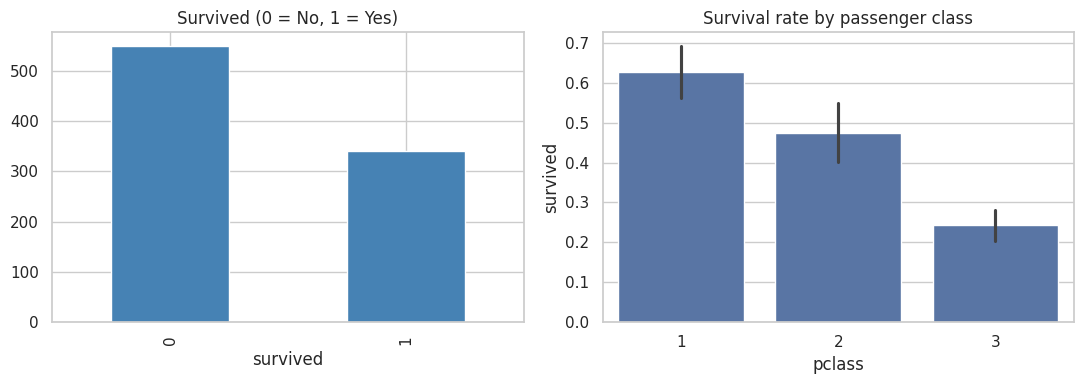

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

df_clean['survived'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Survived (0 = No, 1 = Yes)')

sns.barplot(data=df_clean, x='pclass', y='survived', ax=axes[1])
axes[1].set_title('Survival rate by passenger class')

plt.tight_layout()
plt.show()


## 5. Part A — Classification: Will a passenger survive?

### 5.1 Preprocessing
Split into train/test, then scale the features. **Rule:** fit the scaler on training data only, then transform both sets.

In [8]:
X_cls = df_encoded.drop(columns=['survived'])
y_cls = df_encoded['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape, "| Test shape:", X_test_scaled.shape)


Train shape: (711, 8) | Test shape: (178, 8)


### 5.2 Train a Logistic Regression model

In [9]:
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_scaled, y_train)

preds = clf.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, preds))


Accuracy: 0.8089887640449438


### 5.3 Evaluate
Accuracy alone doesn't tell the whole story — the confusion matrix shows *which* mistakes the model makes.

                 precision    recall  f1-score   support

Did not survive       0.82      0.88      0.85       110
       Survived       0.78      0.69      0.73        68

       accuracy                           0.81       178
      macro avg       0.80      0.79      0.79       178
   weighted avg       0.81      0.81      0.81       178



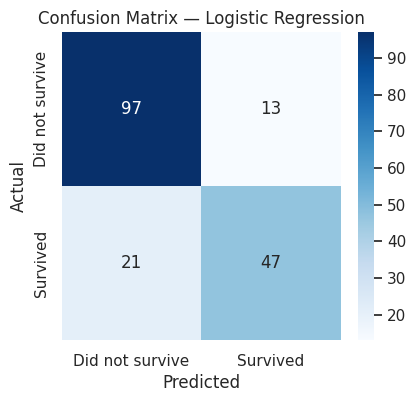

In [10]:
print(classification_report(y_test, preds, target_names=['Did not survive', 'Survived']))

cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Did not survive', 'Survived'],
            yticklabels=['Did not survive', 'Survived'])
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Confusion Matrix — Logistic Regression')
plt.show()


## 6. Part B — Regression: Predicting the ticket fare

Same dataset, different question: instead of a category (survived or not), predict a continuous number — the `fare` a passenger paid, from their other details.

### 6.1 Preprocessing

In [11]:
X_reg = df_encoded.drop(columns=['survived', 'fare'])
y_reg = df_encoded['fare']

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

scaler_r = StandardScaler()
Xr_train_scaled = scaler_r.fit_transform(Xr_train)
Xr_test_scaled = scaler_r.transform(Xr_test)

print("Train shape:", Xr_train_scaled.shape, "| Test shape:", Xr_test_scaled.shape)


Train shape: (711, 7) | Test shape: (178, 7)


### 6.2 Train a Linear Regression model

In [12]:
reg = LinearRegression()
reg.fit(Xr_train_scaled, yr_train)

preds_r = reg.predict(Xr_test_scaled)


### 6.3 Evaluate

In [13]:
mae = mean_absolute_error(yr_test, preds_r)
rmse = np.sqrt(mean_squared_error(yr_test, preds_r))
r2 = r2_score(yr_test, preds_r)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2:   {r2:.2f}")


MAE:  21.14
RMSE: 41.75
R2:   0.35


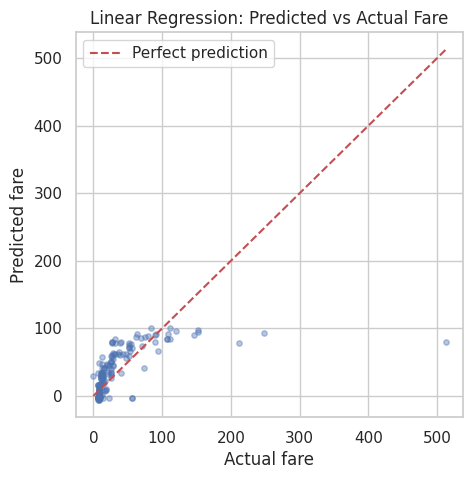

In [14]:
plt.figure(figsize=(5, 5))
plt.scatter(yr_test, preds_r, alpha=0.4, s=15)
lims = [0, yr_test.max()]
plt.plot(lims, lims, 'r--', label='Perfect prediction')
plt.xlabel('Actual fare'); plt.ylabel('Predicted fare')
plt.title('Linear Regression: Predicted vs Actual Fare')
plt.legend()
plt.show()


## 7. Recap

| Step | Classification | Regression |
|---|---|---|
| Question | Did they survive? | How much did they pay? |
| Target | Category (0/1) | Continuous number (₹/$ fare) |
| Model | Logistic Regression | Linear Regression |
| Key metric | Accuracy, confusion matrix | MAE / RMSE / R² |

Both are **supervised learning** — every row has a known correct answer to learn from. The pipeline shape (collect → clean → encode → split → scale → train → evaluate) is identical for both; only the model and the metrics change based on what type of value you're predicting.

## 8. Exercises (try before next session)
1. Add `pclass` and `sibsp` more prominently — does removing them hurt classification accuracy?
2. In Part A, try training *without* scaling. Does Logistic Regression's accuracy change?
3. In Part B, look at which passengers have the biggest prediction errors. Any pattern (e.g. class, age)?
4. Try predicting `age` instead of `fare` in Part B — you'll need to drop rows where the real `age` was filled in, since those aren't real answers to learn from.
